In [ ]:
# from google.colab import files
# uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


### **1. Import the required packages**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

### **2. Reading and Exploring the data**

In [2]:
customers = pd.read_csv('Mall_Customers.csv')

In [3]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
customers.shape

(200, 5)

In [5]:
customers.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
customers.duplicated().sum()

0

In [7]:
customers.drop_duplicates(inplace = True)

In [8]:
customers.drop(columns = 'CustomerID', inplace = True)

### **Machine Learning Process**

In [9]:
customers.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
X = customers.iloc[:, 2:4].values

### **Choose or find the number of clusters**

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
wcss = []

for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++')
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[269981.28000000014,
 186648.03439866513,
 106348.37306211119,
 73679.78903948837,
 44448.45544793369,
 37265.86520484345,
 30227.60651315203,
 25022.485004530332,
 23198.91693739597,
 21619.599321526857]

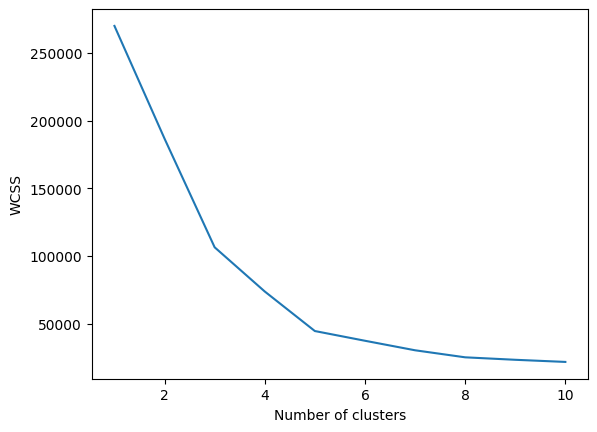

In [ ]:
#plot the elbow graph

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

**The total number of cluster is 5.**

### Apply the KMeans algorithm for final time on the data with k= 5.

In [ ]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++')

kmeans.fit(X)  #start creating the clusters

Y = kmeans.predict(X)  #predict the cluster number for each data point

In [ ]:
Y

array([0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 1,
       0, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 1, 3, 2, 3, 2, 3,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

In [ ]:
pd.DataFrame(Y, columns = ['Cluster Number'])

,Cluster Number
0,0
1,4
2,0
3,4
4,0
...,...
195,3
196,2
197,3
198,2


In [ ]:
output = pd.DataFrame(Y, columns = ['Cluster_Number'])

In [ ]:
final_data = pd.concat([customers, output], axis = 1)

In [ ]:
final_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Number
0,Male,19,15,39,3
1,Male,21,15,81,2
2,Female,20,16,6,3
3,Female,23,16,77,2
4,Female,31,17,40,3


In [ ]:
grp_by_cluster = final_data.groupby('Cluster_Number')

In [ ]:
grp_by_cluster.groups

{0: [123, 125, 127, 129, 131, 133, 135, 137, 139, 141, 143, 145, 147, 149, 151, 153, 155, 157, 159, 161, 163, 165, 167, 169, 171, 173, 175, 177, 179, 181, 183, 185, 187, 189, 191, 193, 195, 197, 199], 1: [43, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 126, 132, 142], 2: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 45], 3: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44], 4: [124, 128, 130, 134, 136, 138, 140, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198]}

In [ ]:
less_income_high_spending = grp_by_cluster.get_group(2)

In [ ]:
less_income_high_spending

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Number
1,Male,21,15,81,2
3,Female,23,16,77,2
5,Female,22,17,76,2
7,Female,23,18,94,2
9,Female,30,19,72,2
11,Female,35,19,99,2
13,Female,24,20,77,2
15,Male,22,20,79,2
17,Male,20,21,66,2
19,Female,35,23,98,2


### **Visualizing the Cluster**

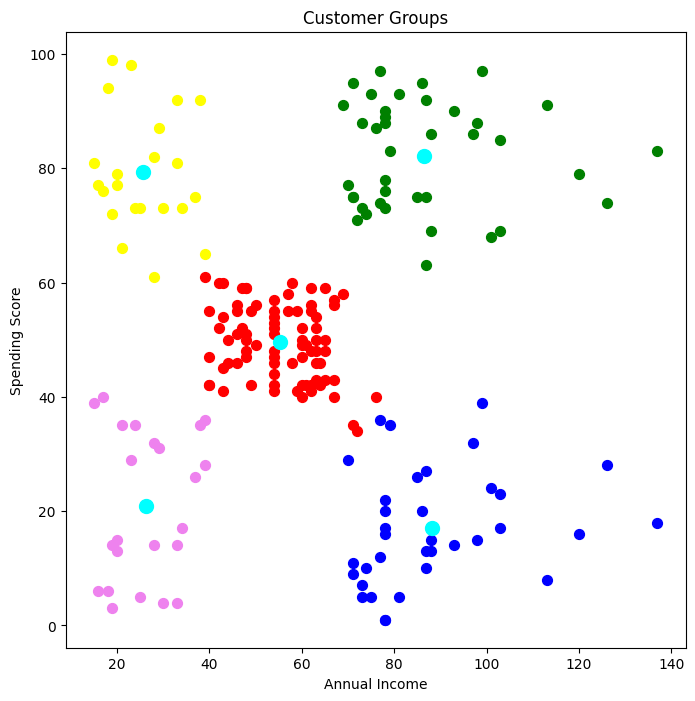

In [ ]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()